<a href="https://colab.research.google.com/github/AartiP87/assignment-01-Bitsom_BA_2511841/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers seaborn

In [ ]:
from sentence_transformers import SentenceTransformer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler took five wickets in a thrilling game",
    "Fielders saved crucial runs near the boundary",
    "The team won the match in the last over",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements of flour and sugar",
    "The recipe includes spices and herbs for better flavor",

    # Cybersecurity (3)
    "Strong passwords are essential for protecting online accounts",
    "Cyber attacks can compromise sensitive user data",
    "Encryption helps secure communication over the internet"
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.00000036e+00  5.67889690e-01  3.05369020e-01  5.25376260e-01
  -1.91681385e-02  1.40678883e-01 -1.44450925e-02 -1.05747432e-02
   8.50398764e-02  2.24747602e-03]
 [ 5.67889690e-01  1.00000000e+00  2.91636229e-01  3.87488127e-01
   1.39763862e-01  9.88066792e-02  8.24687481e-02  9.33622383e-03
   1.10374928e-01  7.83695579e-02]
 [ 3.05369020e-01  2.91636229e-01  1.00000012e+00  1.90273121e-01
  -1.48057584e-02  7.80875906e-02  5.40991724e-02  1.06854461e-01
   1.28752738e-01 -5.42961061e-06]
 [ 5.25376260e-01  3.87488127e-01  1.90273121e-01  1.00000024e+00
   5.71881607e-03 -3.35981399e-02  2.64544860e-02 -4.69108447e-02
   4.08422872e-02  5.29366583e-02]
 [-1.91681385e-02  1.39763862e-01 -1.48057584e-02  5.71881607e-03
   1.00000012e+00  1.54339895e-01  4.39695954e-01 -2.54061166e-02
   2.93371268e-03  4.52164412e-02]
 [ 1.40678883e-01  9.88066792e-02  7.80875906e-02 -3.35981399e-02
   1.54339895e-01  1.00000012e+00  6.83305115e-02 -3.14499065e-02
   4.01365459e-02  5.46358339e-02

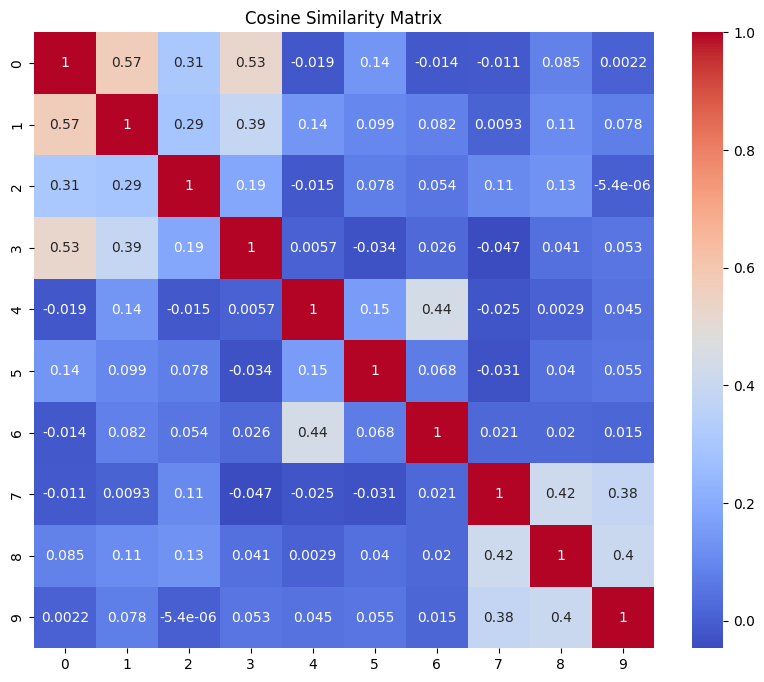

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

In [ ]:
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The bowler took five wickets in a thrilling game
Similarity Score: 0.7890

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

